In [ ]:
#Import libraries
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/initial-dataset/mars_for_students.npz
/kaggle/input/mars-for-students/mars_for_students.npz
/kaggle/input/bright-dataset/dataset_bright_clip.npz
/kaggle/input/bright-dataset/dataset_bright.npz


In [ ]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
import random
import cv2
import tensorflow as tf
from tensorflow import keras as tfk
from tensorflow.keras import layers as tfkl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

%matplotlib inline

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tfk.__version__}")
print(f"GPU devices: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow version: 2.16.1
Keras version: 3.3.3
GPU devices: 0


### Load Dataset

In [ ]:
#Load data
data = np.load("/kaggle/input/initial-dataset/mars_for_students.npz")

training_set = data["training_set"]

X_train = training_set[:, 0]
y_train = training_set[:, 1]

X_test = data["test_set"]

print(f"Training X shape: {X_train.shape}")
print(f"Training y shape: {y_train.shape}")
print(f"Test X shape: {X_test.shape}")

num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")

Training X shape: (2615, 64, 128)
Training y shape: (2615, 64, 128)
Test X shape: (10022, 64, 128)
Number of classes: 5


# Visualize dataset

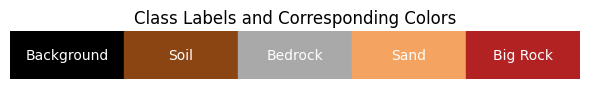

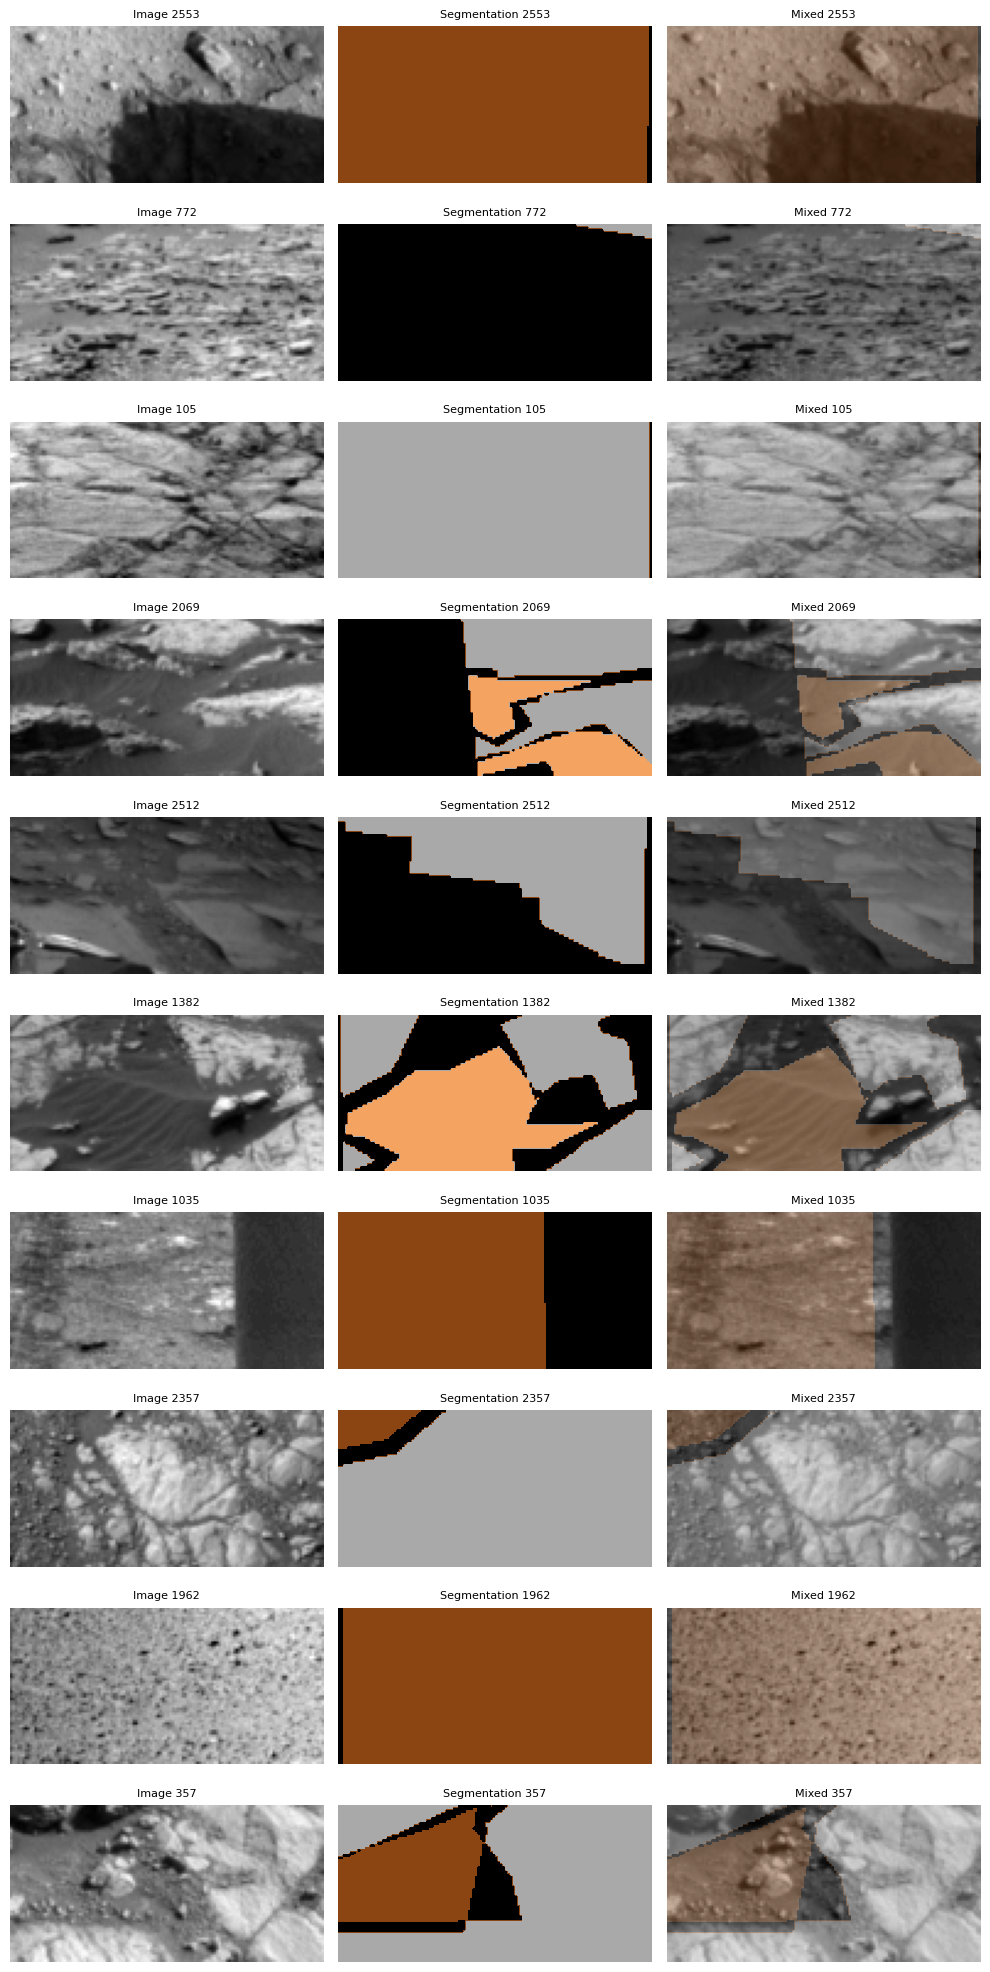

In [ ]:
# Number of images to show
num_images = 10

random_indices = random.sample(range(len(X_train)), num_images)

class_labels = {
    0: 'Background',
    1: 'Soil',
    2: 'Bedrock',
    3: 'Sand',
    4: 'Big Rock'
}

# personalized colors
class_colors = ['#000000', '#8B4513', '#A9A9A9', '#F4A460', '#B22222']

# personalized colormap
cmap_personal = ListedColormap(class_colors)

fig_legend, ax_legend = plt.subplots(figsize=(6, 1))

# Table for the correspondence between colors and labels
for i, color in enumerate(class_colors):
    ax_legend.add_patch(plt.Rectangle((i / len(class_labels), 0), 1 / len(class_labels), 1, color=color))
    ax_legend.text((i + 0.5) / len(class_labels), 0.5, class_labels[i], ha='center', va='center', fontsize=10, color='white')

ax_legend.set_xlim(0, 1)
ax_legend.set_ylim(0, 1)
ax_legend.axis('off')
plt.title("Class Labels and Corresponding Colors", fontsize=12)
plt.tight_layout()
plt.show()

# Grid for the images
fig, axes = plt.subplots(num_images, 3, figsize=(10, 2 * num_images))

# Plot of Images, Mask and overlapping
for i, ax in enumerate(axes):
    image = X_train[random_indices[i]]
    mask = y_train[random_indices[i]]

    ax[0].imshow(image, cmap='gray')
    ax[0].set_title(f"Image {random_indices[i]}", fontsize=8)
    ax[0].axis('off')

    ax[1].imshow(mask, cmap=cmap_personal,vmin=0, vmax=4)
    ax[1].set_title(f"Segmentation {random_indices[i]}", fontsize=8)
    ax[1].axis('off')

    ax[2].imshow(image, cmap='gray')
    ax[2].imshow(mask, cmap=cmap_personal, alpha=0.35,vmin=0, vmax=4)
    ax[2].set_title(f"Mixed {random_indices[i]}", fontsize=8)
    ax[2].axis('off')

plt.tight_layout()
plt.show()


# Removing outliers

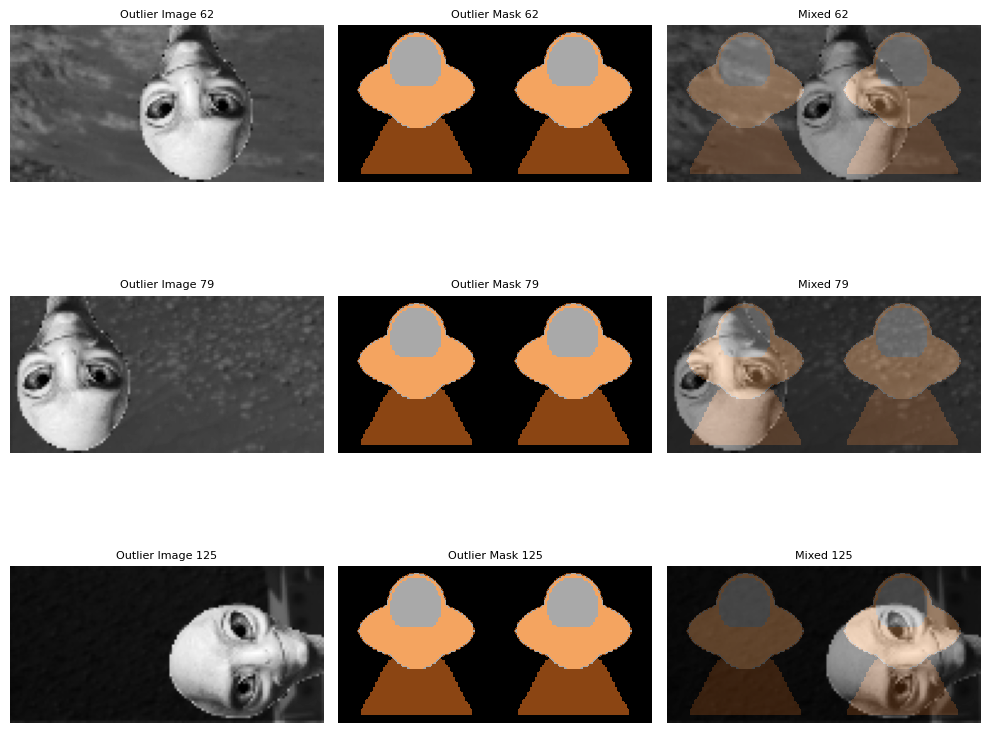

Numero di outliers identificati: 110
Training X shape: (2505, 64, 128)
Training y shape: (2505, 64, 128)


In [ ]:
#one of the outliers' index
outlier_index = 365

outlier_mask = y_train[outlier_index]

outliers = []
outlier_indices = []

# Matching all images' mask with the outlier's mask so to find all the outliers
for i in range(len(X_train)):

    current_mask = y_train[i]

    if np.array_equal(outlier_mask, current_mask):
        outliers.append((X_train[i], y_train[i]))
        outlier_indices.append(i)

# Plot of three outliers example
num_outliers_to_show = min(3, len(outliers))

fig, axes = plt.subplots(num_outliers_to_show, 3, figsize=(10, 3 * num_outliers_to_show))

for i in range(num_outliers_to_show):
    outlier_image, outlier_mask = outliers[i]

    axes[i, 0].imshow(outlier_image, cmap='gray')
    axes[i, 0].set_title(f"Outlier Image {outlier_indices[i]}", fontsize=8)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(outlier_mask, cmap=cmap_personal, vmin=0, vmax=4)  # Usa la colormap personalizzata
    axes[i, 1].set_title(f"Outlier Mask {outlier_indices[i]}", fontsize=8)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(outlier_image, cmap='gray')
    axes[i, 2].imshow(outlier_mask, cmap=cmap_personal, alpha=0.35, vmin=0, vmax=4)  # Usa la colormap personalizzata
    axes[i, 2].set_title(f"Mixed {outlier_indices[i]}", fontsize=8)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# deleting of the outliers of the original dataset
X_train_clean = np.delete(X_train, outlier_indices, axis=0)
y_train_clean = np.delete(y_train, outlier_indices, axis=0)
print(f"Numero di outliers identificati: {len(outliers)}")
print(f"Training X shape: {X_train_clean.shape}")
print(f"Training y shape: {y_train_clean.shape}")
X_train = X_train_clean
y_train = y_train_clean


## AUTOCONTRAST E AUTOBRIGHTNESS

In [ ]:
#function used to adjust the contrast of the images
def autocontrast(X_train):
    X_train_autocontrast = np.zeros_like(X_train, dtype=np.uint8)

    for i in range(X_train.shape[0]):
        img = X_train[i].astype(np.uint8)

        # Istogram Equalization
        img_equalized = cv2.equalizeHist(img)
        X_train_autocontrast[i] = img_equalized

    return X_train_autocontrast

#function used to adjust the Brightness of the images
def autobrightness(X_train, brightness_target=133.5, bright_threshold=200, dark_threshold=0, brightness_factor=1.2, clip_limit=0.002):
    X_train_autobrightness = np.zeros_like(X_train, dtype=np.uint8)

    for i in range(X_train.shape[0]):
        img = X_train[i].astype(np.float32)

        # mean brightness
        mean_brightness = np.mean(img)

        # correction factor
        brightness_correction = brightness_target / mean_brightness * brightness_factor

        img_brightened = img.copy()

        # Apply correction with appropriate clip
        for y in range(img.shape[0]):
            for x in range(img.shape[1]):
                if img[y, x] < bright_threshold and img[y, x] > dark_threshold:
                    img_brightened[y, x] = min(255, img[y, x] * brightness_correction)

        img_brightened = img_brightened.astype(np.uint8)

        clahe = cv2.createCLAHE(clipLimit=clip_limit * 255, tileGridSize=(8,8))
        img_final = clahe.apply(img_brightened)

        X_train_autobrightness[i] = img_final

    return X_train_autobrightness

#### FUNZIONI DI DISPLAY

In [ ]:
#Spectrum histogram Display Function
def display_spectrum_comparison(image, image_brightness, image_contrast, image_contrast_brightness):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    titles = ['Original', 'Brightness', 'Contrast', 'Contrast+Brightness']

    images = [image,  image_brightness, image_contrast, image_contrast_brightness]

    colors = ['black', 'blue', 'red', 'green']

    for ax, img, title, color in zip(axes, images, titles, colors):
        ax.hist(img.ravel(), bins=256, histtype='step', color=color)
        ax.set_title(f"{title} Histogram")
        ax.set_xlabel("Pixel Value")
        ax.set_ylabel("Frequency")

        ax.text(0.05, 0.95, f"Mean: {np.mean(img):.2f}\nStd: {np.std(img):.2f}",
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.show()

#Images display comparison function
def display_images_comparison(X_train, X_train_brightness, X_train_contrast, X_train_contrast_brightness,
                               num_images=3, image_height=4):

    num_images = min(num_images, X_train.shape[0])

    random_indices = np.random.choice(range(X_train.shape[0]), num_images, replace=False)

    figsize = (20, num_images * image_height)

    fig, axes = plt.subplots(num_images, 4, figsize=figsize)

    col_titles = ['Original', 'Brightness', 'Contrast', 'Contrast+Brightness']

    for row, idx in enumerate(random_indices):
        images = [
            X_train[idx],
            X_train_brightness[idx],
            X_train_contrast[idx],
            X_train_contrast_brightness[idx]
        ]

        for col, (img, title) in enumerate(zip(images, col_titles)):
            if num_images == 1:
                ax = axes[col]
            else:
                ax = axes[row, col]

            ax.imshow(img, cmap='gray')
            ax.set_title(f'{title} (Img {idx})')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

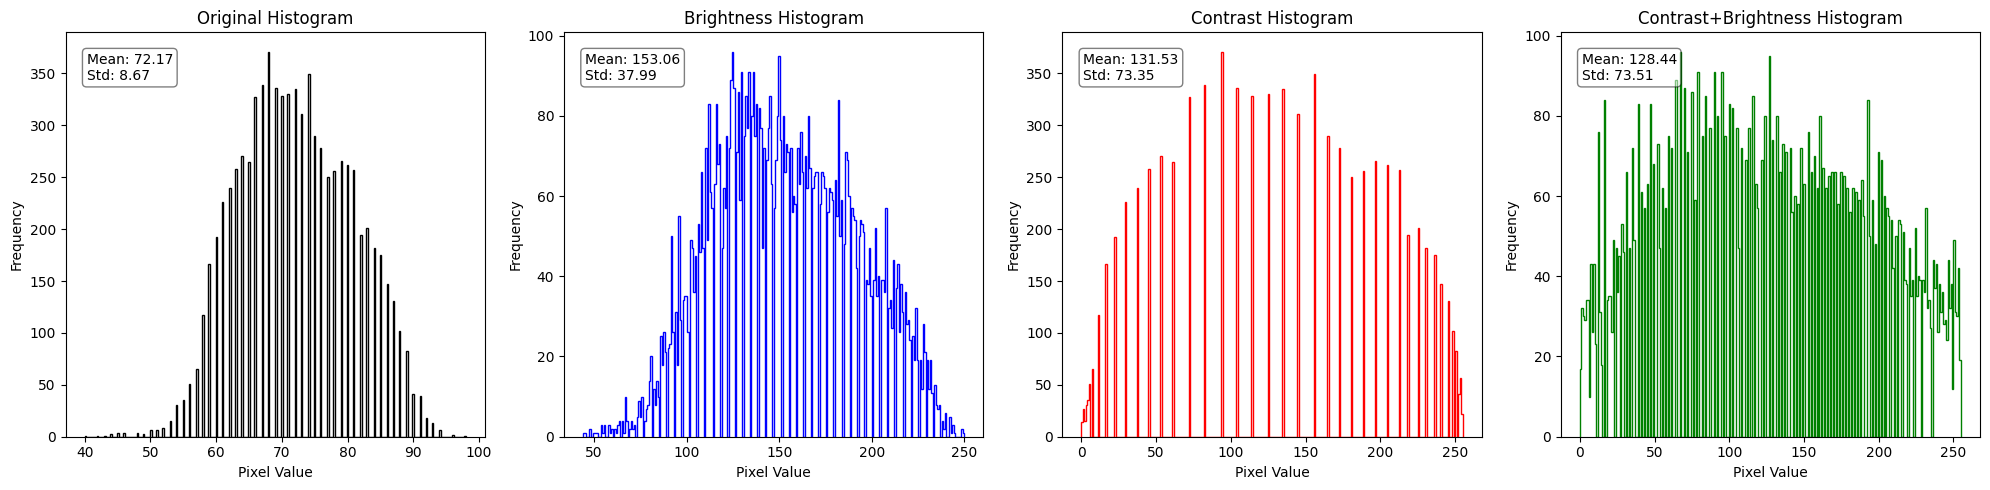

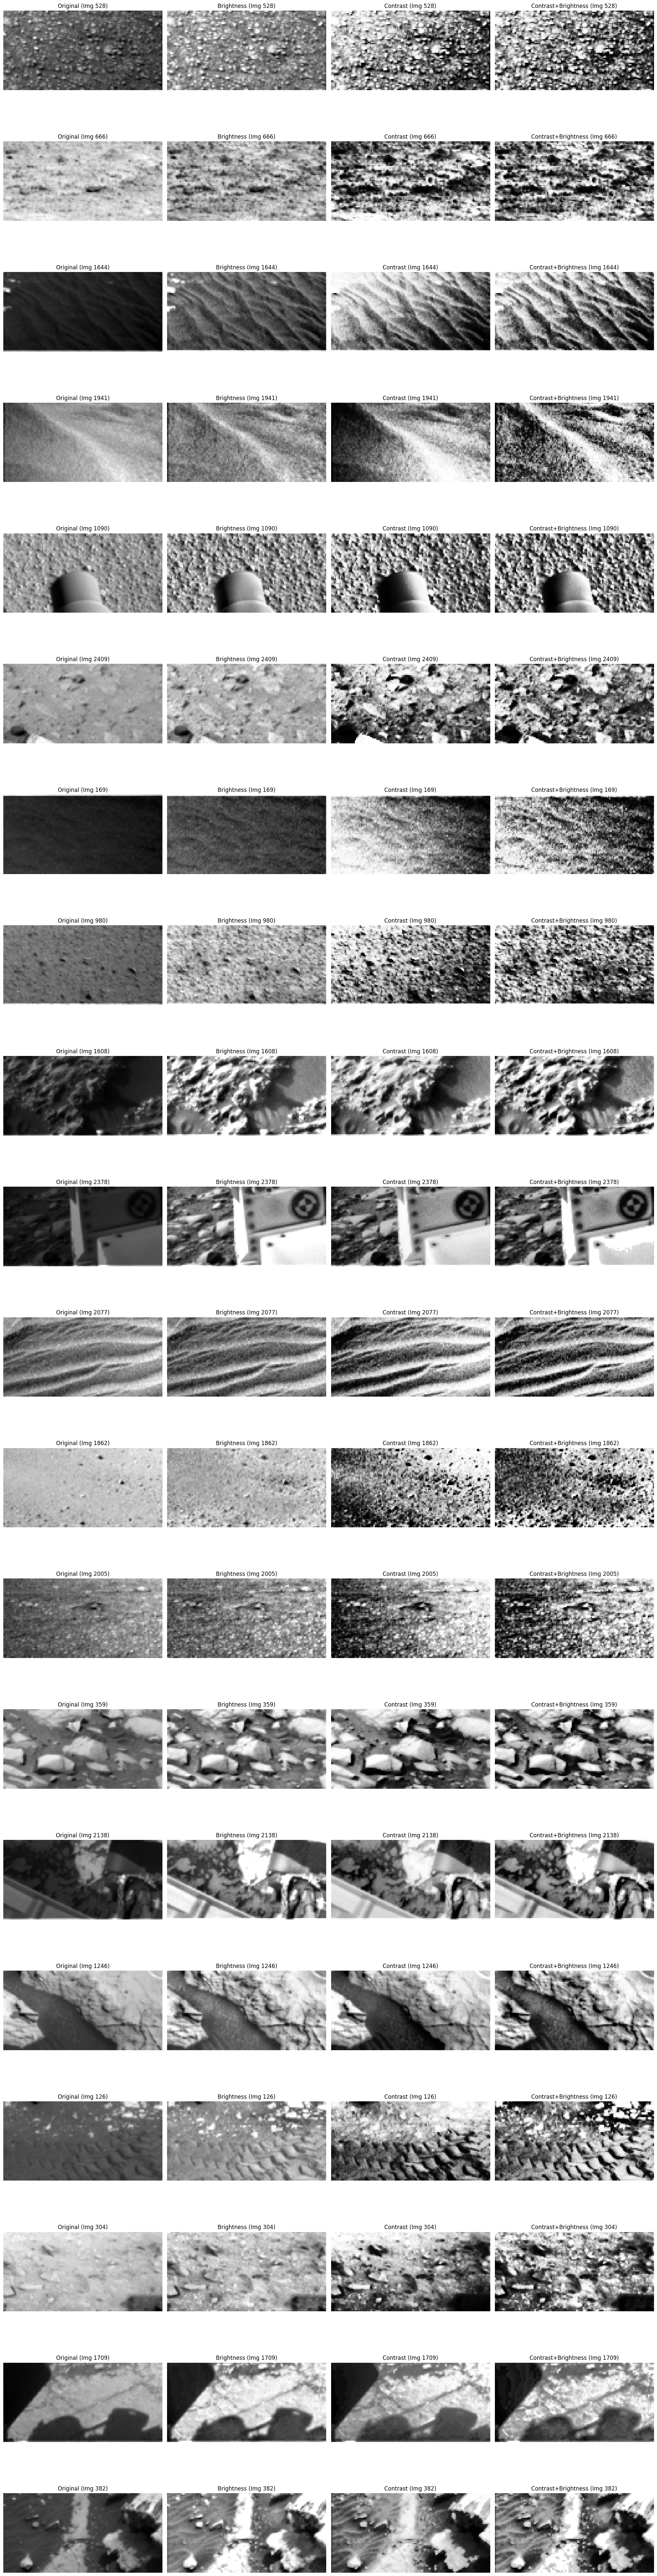

In [ ]:
# Applicatino of the above descripted funcitons

X_train_brightness=autobrightness(X_train, clip_limit=0.02, brightness_factor=1.1)
X_train_contrast=autocontrast(X_train)
X_train_bright_contrast = autocontrast(X_train_brightness)

# Displaying

display_spectrum_comparison(
    X_train[0],
    X_train_brightness[0],
    X_train_contrast[0],
    X_train_bright_contrast[0]
)

display_images_comparison(
    X_train,
    X_train_brightness,
    X_train_contrast,
    X_train_bright_contrast,
    num_images=20,
    image_height=4
)

In [ ]:
# Apply the Function you prefer

X_train=autobrightness(X_train, clip_limit=0.02, brightness_factor=1.1)
X_test=autobrightness(X_test, clip_limit=0.02, brightness_factor=1.1)


In [ ]:
# print for checking
print(f"Training X shape: {X_train.shape}")
print(f"Training X shape: {X_test.shape}")

Training X shape: (2505, 64, 128)
Training X shape: (10022, 64, 128)


## Saving New Dataset

In [ ]:
def save_datasets(X_train, y_train, X_test, filename="bright_clip.npz"):

    np.savez_compressed(filename,
                         X_train=X_train, y_train=y_train,
                         X_test=X_test)
    print(f"Dataset salvato come {filename}")

In [ ]:
np.savez('dataset_bright_clip.npz', X_train=X_train, y_train=y_train, X_test=X_test)
